# Error models for $\alpha + {}^{44}$Ca elastic scattering: a comparison by evidence

This notebook is a small study rather than a demonstration.  We have one real
measurement and one optical potential, and the only thing we vary is the **error
model** — four different statements about what the disagreement between model
and data means.  Then we ask the data which statement they prefer, by
[Bayesian evidence](https://en.wikipedia.org/wiki/Marginal_likelihood), and
separately by how well each one predicts angles it was never shown.

The data are the differential elastic cross sections, as a ratio to Rutherford,
of $^{44}$Ca($\alpha,\alpha$) at 29 MeV from
[EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567),
[Oeschler *et al.*, Phys. Rev. Lett. **28**, 694 (1972)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694).
Oeschler *et al.* report no uncertainties at all, so every rung below has to
infer its own — which is precisely what makes the comparison interesting.

See also the [`jitr` quickstart tutorials](https://beykyle.github.io/jitr/getting-started.html).
In a sense this notebook is their successor: with `rxmc` we can build more
careful statistical models on the same physics, including
[Gaussian processes for model discrepancy](https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/1467-9868.00294).

Recipes: 10, 11, 13, 17, 18

In [1]:
import corner
import dynesty
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotstyle
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## The data

We take every fourth angle of the $^{44}$Ca set: 73 points from 15 to 174
degrees, enough to pin the diffraction pattern without making every fit four
times slower.  A ratio to Rutherford is dimensionless, so nothing needs
converting; the kinematics the model needs go in `meta`, and there are no errors
to report.

In [2]:
df = pd.read_csv("data/alpha_ca_ratio_ruth.csv")
df = df[df["target"] == "Ca44"].iloc[::4]
reaction = jitr.reactions.ElasticReaction(target=(44, 20), projectile=(4, 2))
E_lab = 29.0
meta = {"reaction": reaction, "Elab": E_lab, "quantity": "dXS/dRuth"}
angles = np.deg2rad(df["angle_cm_deg"].to_numpy())
ratio = df["ratio_to_rutherford"].to_numpy()
data = rx.Dataset(
    angles, ratio, np.zeros(ratio.size), label="44Ca(a,a) 29 MeV", meta=meta
)
x_fine = np.deg2rad(np.linspace(10.0, 178.0, 220))
print(
    f"{data.n} points between {np.rad2deg(angles.min()):.0f} and "
    f"{np.rad2deg(angles.max()):.0f} degrees"
)

73 points between 15 and 174 degrees


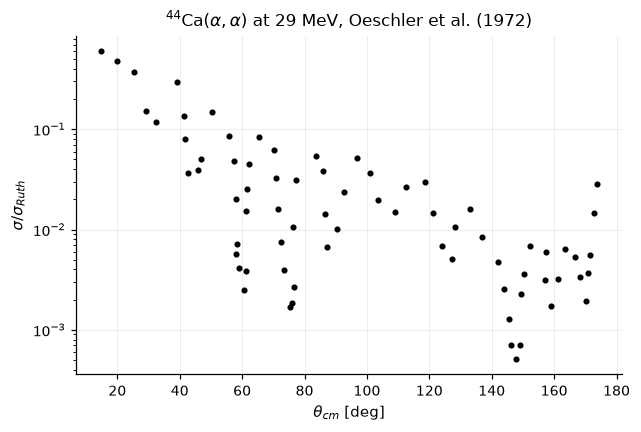

In [3]:
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title=r"$^{44}$Ca($\alpha,\alpha$) at 29 MeV, Oeschler et al. (1972)",
)
plt.show()

## The optical model

As in the `jitr` quickstart: a Woods-Saxon potential plus the Coulomb potential
of a uniformly charged sphere of radius $1.3\,A^{1/3}$ fm, with radii in units
of $A^{1/3}$ fm.  The real and imaginary volume terms share one geometry, so
four parameters are free: $V$, $W$, $r$, $a$.  Priors follow the quickstart's
typical $\alpha$-nucleus values, truncated at zero (recipe 13).

Thirty partial waves are converged at this energy, and the default basis size
sits within a few per cent of the fully converged solver at the deepest minima —
far below any of the error models below, and two hundred times faster.

In [4]:
A13 = 44 ** (1 / 3)


def central(r, V, W, R, a):
    return -(V + 1j * W) * woods_saxon_safe(r, R * A13, a)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


params = [
    rx.Parameter("V", prior=stats.norm(150.0, 20.0), bounds=(0.0, np.inf), latex="V"),
    rx.Parameter("W", prior=stats.norm(20.0, 10.0), bounds=(0.0, np.inf), latex="W"),
    rx.Parameter("r", prior=stats.norm(1.4, 0.3), bounds=(0.8, 2.0), latex="r"),
    rx.Parameter("a", prior=stats.norm(0.5, 0.2), bounds=(0.2, 1.0), latex="a"),
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    lambda r: 0.0 * r,
    lambda ws, *x: (tuple(x), (), ()),
    params,
    coulomb=coulomb,
    lmax=30,
)
theta_0 = np.array([150.0, 20.0, 1.4, 0.5])

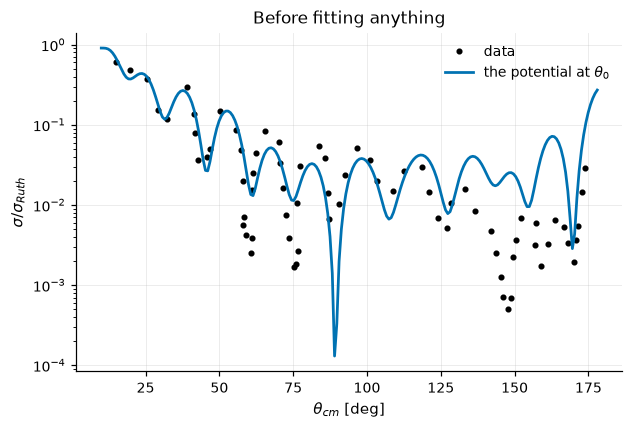

In [5]:
# the model is always drawn on a fine grid: evaluated only at the (downsampled)
# data angles, the diffraction pattern aliases and the curve looks ragged
on_fine = omp.bind(x_fine, meta)
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.plot(
    np.rad2deg(x_fine),
    on_fine(*theta_0),
    color=plotstyle.COLOURS[0],
    label=r"the potential at $\theta_0$",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Before fitting anything",
)
ax.legend()
plt.show()

## The error-model ladder

The data span three decades and their errors were never reported, but they are
presumably multiplicative, so we compare in **log space** (recipe 10):
`space=tf.log` transforms the data once and every prediction with it, and
`problem.log_jacobian()` is what later makes a log-space evidence comparable
with a linear-space one.

With nothing reported, every rung sets `statistical=False`: the inferred terms
*are* the covariance.

| label | error model |
|---|---|
| `L0` | constant noise in log space, $\sigma = \epsilon$ on every point |
| `E0` | fractional noise in linear space, $\sigma_i = \epsilon\, y_{m,i}$ |
| `L2y` | `L0` plus a free normalisation mode, $\eta\, y_m$ (the `jitr` notebook's model) |
| `Lgp` | `L0` plus a Matérn(5/2) Gaussian process in $u = \theta/\pi$ with a free amplitude |

The same `log_eps` object is reused across rungs, and each `Problem` compiles
independently (recipe 18).  The priors are log-uniform on the error scales
between 5 % and 200 %, as in the `jitr` notebook (recipe 13).

In [6]:
comp_log = rx.Comparison(data, omp, space=tf.log)
comp_lin = rx.Comparison(data, omp)
log_eps = rx.Parameter(
    "log_eps",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\epsilon",
)
log_eta = rx.Parameter(
    "log_eta",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\eta",
)
log_amp = rx.Parameter(
    "log_A",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log A",
)
log_ell = rx.Parameter(
    "log_ell",
    prior=stats.uniform(np.log(0.02), np.log(1.0) - np.log(0.02)),
    latex=r"\log\ell",
)
gp = T.kernel(
    Matern(0.1, nu=2.5),
    on=comp_log,
    coords=lambda x: x / np.pi,
    amplitude=T.constant_amplitude,
    amplitude_params=(log_amp,),
    params=[log_ell],
)

In [7]:
ladder = {
    "L0": rx.Constraint([comp_log], terms=[T.noise(log_eps)], statistical=False),
    "E0": rx.Constraint(
        [comp_lin], terms=[T.noise_fraction(log_eps)], statistical=False
    ),
    "L2y": rx.Constraint(
        [comp_log],
        terms=[T.noise(log_eps), T.normalization(log_eta)],
        statistical=False,
    ),
    "Lgp": rx.Constraint([comp_log], terms=[T.noise(log_eps), gp], statistical=False),
}
problems = {name: rx.Problem([c]) for name, c in ladder.items()}
for name, p in problems.items():
    print(f"{name:4s} columns: {p.names}")

L0   columns: ['V', 'W', 'r', 'a', 'log_eps']
E0   columns: ['V', 'W', 'r', 'a', 'log_eps']
L2y  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_eta']
Lgp  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_ell', 'log_A']


## Running the ladder

Optical-model posteriors are correlated and often multimodal, so we use nested
sampling: [dynesty](https://dynesty.readthedocs.io/) copes with them, and it
returns the evidence we are about to compare as a by-product.

In [8]:
def fit_nested(problem, seed, nlive=80, dlogz=1.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    return sampler.results

In [9]:
results, samples = {}, {}
for i, (name, p) in enumerate(problems.items()):
    res = fit_nested(p, seed=i)
    results[name] = res
    samples[name] = res.samples_equal(rstate=np.random.default_rng(i))
    print(
        f"{name:4s} log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}   "
        f"{int(np.sum(res.ncall)):6d} calls"
    )

L0   log Z =  -101.42 +/- 0.95    26153 calls


E0   log Z =   211.36 +/- 1.03    34980 calls


L2y  log Z =   -98.22 +/- 0.85    22672 calls


Lgp  log Z =   -92.18 +/- 0.95    30383 calls


## Evidence, and what a Bayes factor is

The [marginal likelihood](https://en.wikipedia.org/wiki/Marginal_likelihood), or
evidence, is the probability the model assigns to the data *before* we see which
parameters fit best:

$$Z = \int p(\mathbf{y} \mid \theta)\, p(\theta)\, \mathrm{d}\theta .$$

It rewards models that put probability where the data landed and penalises those
that spread it thinly over parameter space they did not need — an automatic
Occam's razor.  The ratio of two evidences is the
[Bayes factor](https://en.wikipedia.org/wiki/Bayes_factor), and it is how much
the data shift our relative belief in one error model over another.  Nested
sampling computes $\log Z$ directly, which is the main reason to use it here.

Two practical points.  A Bayes factor depends on the priors, not just the fit,
so the prior widths are part of the claim being made — this is why they are
stated explicitly above.  And evidences computed in different comparison spaces
are not comparable until we add `problem.log_jacobian()`, which is what puts the
log-space rungs into the same units as the linear-space `E0`.  `compare_logz`
returns a tie unless the difference exceeds twice the combined sampler error,
because differences smaller than that are bookkeeping, not evidence.

In [10]:
logz = {
    name: rx.diagnostics.logz_summary(
        results[name].logz[-1] + problems[name].log_jacobian(),
        results[name].logzerr[-1],
    )
    for name in problems
}
print(f"{'rung':5s} {'log Z (linear-space units)':>28s}")
for name, (mean, err, _) in logz.items():
    print(f"{name:5s} {mean:20.2f} +/- {err:.2f}")
best = max(logz, key=lambda n: logz[n][0])
print(f"\nbest rung: {best}")
for name in problems:
    if name != best:
        v = rx.diagnostics.compare_logz(logz[best], logz[name])
        print(
            f"{best} vs {name}: dlogZ = {v['dlogZ']:6.2f} +/- {v['err']:.2f}"
            f"  ->  {v['verdict']}"
        )

rung    log Z (linear-space units)
L0                  213.05 +/- 0.95
E0                  211.36 +/- 1.03
L2y                 216.26 +/- 0.85
Lgp                 222.30 +/- 0.95

best rung: Lgp
Lgp vs L0: dlogZ =   9.24 +/- 1.34  ->  a
Lgp vs E0: dlogZ =  10.93 +/- 1.41  ->  a
Lgp vs L2y: dlogZ =   6.04 +/- 1.28  ->  a


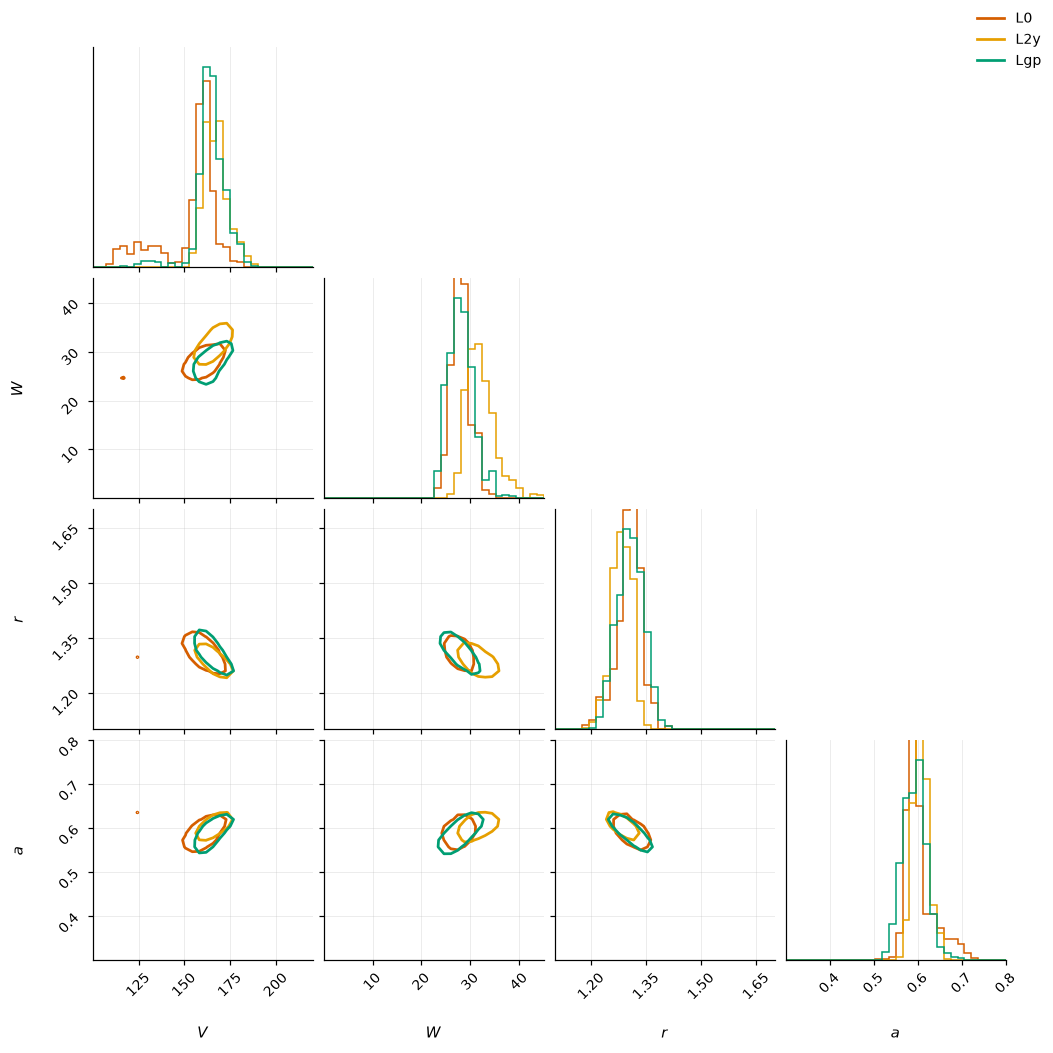

In [11]:
labels = [f"${q.latex}$" for q in params]
fig = None
rungs = [
    ("L0", plotstyle.COLOURS[1]),
    ("L2y", plotstyle.COLOURS[4]),
    ("Lgp", plotstyle.COLOURS[2]),
]
for name, colour in rungs:
    fig = corner.corner(
        samples[name][:, problems[name].columns(params)],
        fig=fig,
        labels=labels,
        range=[(100, 220), (0, 45), (1.1, 1.7), (0.3, 0.8)],
        **plotstyle.corner_kwargs(
            color=colour,
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68,),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in rungs],
    loc="upper right",
    fontsize=9,
)
plt.show()

## What each rung predicts (recipe 17)

Evidence says which error model the data prefer.  It does not say whether any of
them describes the data *well*, and for that we want the posterior predictive:
draws of $y_m(\theta) + \text{noise}$ with the covariance each rung declared,
not merely the spread of the model curve.

`predictive_draws` gives exactly that — the draws include $\Sigma$, so a rung
with a large inferred noise produces wide draws even where its model curve is
sharp.  We compare the three log-space rungs at the measured angles, then check
their calibration.

In [12]:
levels = np.linspace(0.1, 0.9, 9)
draws, coverage = {}, {}
for i, (name, _) in enumerate(rungs):
    p = problems[name]
    c = p.constraints[0]
    draws[name] = rx.diagnostics.predictive_draws(
        p, samples[name][::20], n_rep=2, rng=i
    )
    coverage[name] = rx.diagnostics.coverage_curve(draws[name], c.y[c.active], levels)
    width = rx.diagnostics.sharpness(draws[name], transform=np.exp).mean()
    print(
        f"{name:4s} 68 % predictive width = {width:6.3f} (ratio units)   "
        f"coverage at 0.68 = {rx.diagnostics.coverage_curve(draws[name], c.y[c.active], [0.68])[0]:.2f}"
    )

L0   68 % predictive width =  0.076 (ratio units)   coverage at 0.68 = 0.79


L2y  68 % predictive width =  0.068 (ratio units)   coverage at 0.68 = 0.81


Lgp  68 % predictive width =  0.072 (ratio units)   coverage at 0.68 = 0.78


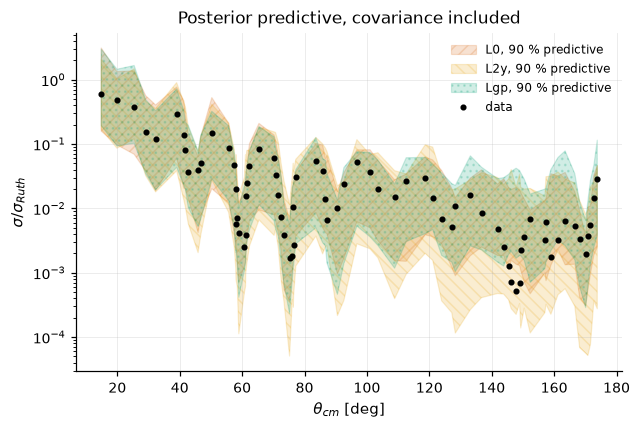

In [13]:
fig, ax = plt.subplots()
for (name, colour), hatch in zip(rungs, plotstyle.HATCHES):
    lo, hi = np.percentile(np.exp(draws[name]), [5, 95], axis=0)
    plotstyle.band(
        ax,
        np.rad2deg(angles),
        lo,
        hi,
        color=colour,
        hatch=hatch,
        label=f"{name}, 90 % predictive",
    )
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Posterior predictive, covariance included",
)
ax.legend(fontsize=8)
plt.show()

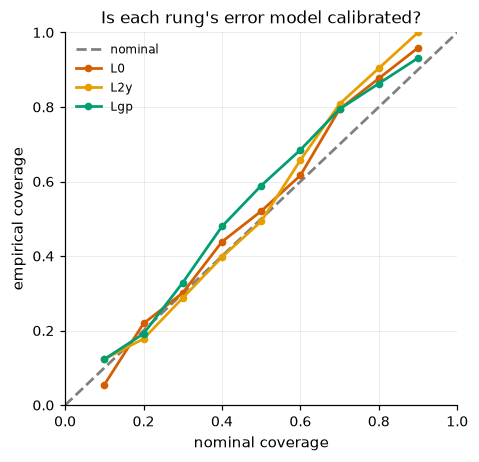

In [14]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
for name, colour in rungs:
    ax.plot(levels, coverage[name], "o-", color=colour, label=name)
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Is each rung's error model calibrated?",
)
ax.legend(fontsize=8)
plt.show()

### Are any of them calibrated?

In sample, all three rungs *over*-cover: 79 %, 81 % and 78 % of the measured
points fall inside their nominal 68 % intervals, with predictive widths of
0.076, 0.068 and 0.072 in ratio units.  The inferred noise is a little more
generous than the data need, which is what we should expect when one noise
parameter has to cover a diffraction pattern whose model error is nowhere near
uniform in angle.

That is the easy question, though: these are the points the fit was shown.  The
held-out section below asks the hard one, and there the three rungs separate
sharply — 49 %, 60 % and 80 % of the backward angles land inside the nominal
68 % band.  Being well calibrated on the data we fitted is no evidence at all
that we will be calibrated on the data we did not.

## Hold out the backward angles (recipe 11)

Fit each rung below 90 degrees and score the points above it: `masked_where`
keeps every object, `complement()` flips the mask, and a chain from the fit
scores the held-out problem directly.  The joint held-out log predictive is a
different question from the evidence: not "which model explains the data we
fitted" but "which model predicts what it has not seen".

The normalisation of `L2y` and the Gaussian process of `Lgp` both couple the
angles we fit to the ones we hold out, so the honest score is not the marginal
density of the held-out points but the conditional
$p(y_\mathrm{held} \mid y_\mathrm{fit}, \theta)$: passing `given=p_fit` to
both diagnostics computes exactly that (recipe 11).  For `L0` nothing couples
the two, and the conditional is the marginal.

In [15]:
cut = np.deg2rad(90.0)
scores = {}
for i, (name, c) in enumerate(ladder.items()):
    if name == "E0":
        continue  # same space as L0 up to the noise model; the log rungs are the comparison
    fit = c.masked_where(lambda x: x < cut)
    p_fit, p_held = rx.Problem([fit]), rx.Problem([fit.complement()])
    res = fit_nested(p_fit, seed=10 + i)
    s = res.samples_equal(rstate=np.random.default_rng(10 + i))
    lp = rx.diagnostics.heldout_log_predictive(p_held, s[::5], given=p_fit)
    held_draws = rx.diagnostics.predictive_draws(
        p_held, s[::20], n_rep=2, rng=i, given=p_fit
    )
    h = p_held.constraints[0]
    cov68 = rx.diagnostics.coverage_curve(held_draws, h.y[h.active], [0.68])[0]
    scores[name] = (
        rx.diagnostics.log_posterior_predictive(lp),
        cov68,
        s,
        p_fit,
        p_held,
    )
    print(
        f"{name:4s} held-out log predictive = {scores[name][0]:8.2f}   "
        f"68 % coverage of the held-out points = {cov68:.2f}"
    )

L0   held-out log predictive =   -60.50   68 % coverage of the held-out points = 0.49


L2y  held-out log predictive =   -55.34   68 % coverage of the held-out points = 0.60


Lgp  held-out log predictive =   -50.45   68 % coverage of the held-out points = 0.80


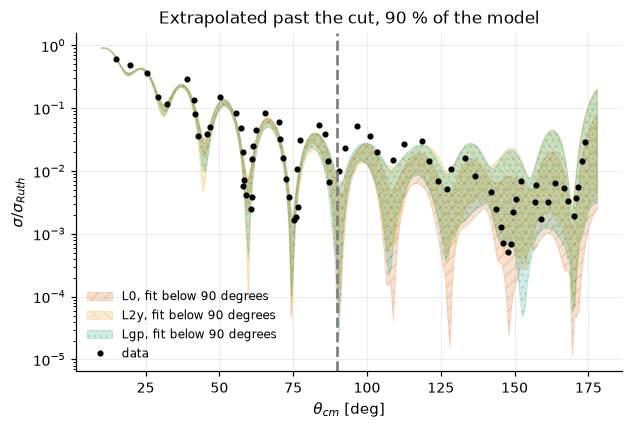

In [16]:
fig, ax = plt.subplots()
for (name, colour), hatch in zip(rungs, plotstyle.HATCHES):
    _, _, s, p_fit, _ = scores[name]
    curves = np.array([on_fine(*row[p_fit.columns(params)]) for row in s[::25]])
    lo, hi = np.percentile(curves, [5, 95], axis=0)
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color=colour,
        hatch=hatch,
        label=f"{name}, fit below 90 degrees",
    )
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.axvline(90.0, color="0.5", ls="--")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Extrapolated past the cut, 90 % of the model",
)
ax.legend(fontsize=8)
plt.show()

## Takeaways

- One comparison, one potential, four covariances: the ladder is a dictionary of
  constraints, and every problem compiles on its own.
- Log space is where multiplicative errors are additive, and the Jacobian is what
  makes its evidence comparable with a linear-space fit.
- Evidence and held-out prediction ask different questions.  Here the GP rung
  wins both.  Scored honestly, conditioned on the forward angles, the
  normalisation rung's intervals are too narrow at the backward angles (60 % of
  the held-out points fall inside the nominal 68 % band) and the GP rung's are
  too wide (80 %): neither is calibrated past the cut, and a rung that explains
  the forward angles best need not predict the backward ones.
- Light-ion potentials are famously ambiguous: several parameter families give
  nearly the same cross section.  The `L0` posterior above carries a second
  family near $V \approx 125$ MeV beside the main one at $V \approx 165$ MeV,
  and it is the prior, not the data, that decides how much weight each gets (see
  the `jitr` calibration notebook on the discrete ambiguity).